# Node classification sweep performance 

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [6]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [7]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [8]:
import wandb
wandb.login()

True

In [11]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison

In [10]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [19]:
GNN_sweep = "9w559haw"
GNN_old_sweep = "l0jetvrz"
InterScale_sweep = ""
PCATrans_sweep = ""

## Graph Classification performance

In [20]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial']

Q: Why does PCATrans not have test_f1 scores?

In [22]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, CLASSES)
GNN_old_wandb = Wandb_evaluation("GCN", GNN_old_sweep, SWEEP_GOAL, CLASSES)
#PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, CLASSES)
#InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [15]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,nc6wcxh4,melton25_clas_node_44_GCN_,44,finished,0.5,150,None,583.736024,255145,0.410172,None,0.074074,0.577701,0.187302,0.483192,0.000000,0.219942,0.0,0.120466
1,n72wxcou,melton25_clas_node_44_GCN_,43,finished,0.5,150,None,610.241567,255145,0.345615,None,0.074074,0.741093,0.150794,0.000000,0.222222,0.160729,0.0,0.000000
2,qrvo7c6z,melton25_clas_node_44_GCN_,42,finished,0.5,150,None,623.258038,255145,0.229102,None,0.211111,0.552431,0.111111,0.012950,0.111111,0.143627,0.0,0.020202
3,ltgzyu44,melton25_clas_node_44_GCN_,41,finished,0.5,150,None,587.714794,255145,0.158501,None,0.111111,0.392892,0.055556,0.008230,0.055556,0.165252,0.0,0.055931
4,o6zttv7w,melton25_clas_node_44_GCN_,40,finished,0.5,150,None,594.628172,255145,0.357124,None,0.111111,0.492742,0.211111,0.474357,0.111111,0.191293,0.0,0.029440


In [29]:
#PCATrans_wandb.get_mean_and_std()

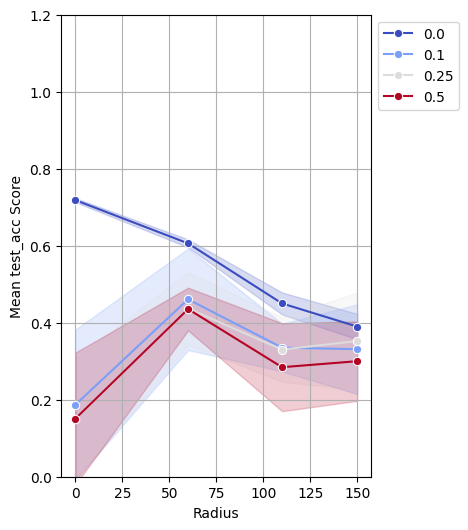

In [39]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

In [47]:
#PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

In [48]:
#InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

  model                      class      mean       std  n_seeds
0   GCN       test_f1_class_Acinar  0.533686  0.183318        5
1   GCN        test_f1_class_Alpha  0.118519  0.134562        5
2   GCN         test_f1_class_Beta  0.191852  0.069409        5
3   GCN       test_f1_class_Ductal  0.296806  0.187825        5
4   GCN    test_f1_class_Endocrine  0.022222  0.049690        5
5   GCN  test_f1_class_Endothelial  0.028740  0.029201        5
6   GCN       test_f1_class_Immune  0.232162  0.085587        5
7   GCN         test_f1_class_Mast  0.022222  0.049690        5


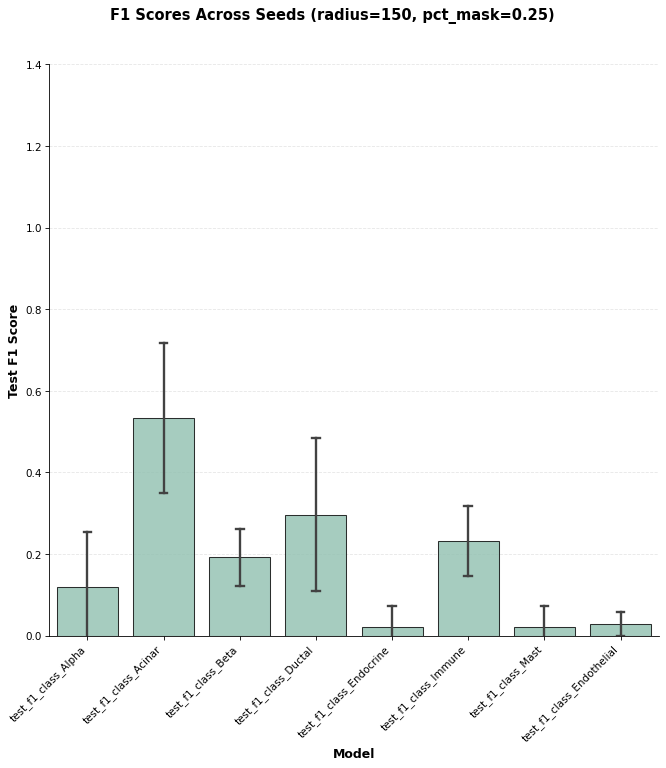

In [28]:
wandb_evals = [GNN_old_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=150,
    pct_mask_nodes=0.25,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)